# SkillCraft Technology – Data Science Internship

# Task 4: Traffic Accident Data Analysis


## Objective

Analyze the US Accidents dataset to identify patterns related to road conditions, weather, and time of day. Visualize accident hotspots and contributing factors using Python.

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Load Dataset

In [2]:
df = pd.read_csv("US_Accidents_March23.csv")

/tmp/ipykernel_2332/1748654041.py:1: DtypeWarning: Columns (29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("US_Accidents_March23.csv")


Explore Dataset

In [3]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
df.shape

(153588, 46)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153588 entries, 0 to 153587
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     153588 non-null  object 
 1   Source                 153588 non-null  object 
 2   Severity               153588 non-null  int64  
 3   Start_Time             153588 non-null  object 
 4   End_Time               153588 non-null  object 
 5   Start_Lat              153588 non-null  float64
 6   Start_Lng              153588 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           153588 non-null  float64
 10  Description            153588 non-null  object 
 11  Street                 153588 non-null  object 
 12  City                   153574 non-null  object 
 13  County                 153588 non-null  object 
 14  State                  153588 non-nu

In [6]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,153588.000000,153588.000000,153588.000000,0.0,0.0,153588.000000,151106.000000,6249.000000,150719.000000,151667.000000,150986.000000,120434.000000,11780.000000
mean,2.432130,33.760695,-110.041544,NaN,NaN,0.023181,68.404722,48.889838,62.541120,29.986767,9.356782,8.162045,0.033414
std,0.498427,3.618916,16.272749,NaN,NaN,0.476435,12.644244,20.065615,22.367167,0.264190,1.856401,6.753651,0.084955
min,1.000000,25.433098,-123.813927,NaN,NaN,0.000000,3.200000,-8.400000,4.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,33.150101,-121.236292,NaN,NaN,0.000000,60.100000,36.400000,48.000000,29.910000,10.000000,4.600000,0.000000
50%,2.000000,34.023262,-118.081863,NaN,NaN,0.010000,68.000000,41.900000,65.000000,29.990000,10.000000,6.900000,0.000000
75%,3.000000,37.323296,-116.326767,NaN,NaN,0.010000,77.000000,64.000000,80.000000,30.080000,10.000000,10.400000,0.030000
max,4.000000,41.428753,-80.050438,NaN,NaN,80.890000,114.100000,111.000000,100.000000,33.040000,80.000000,822.800000,1.680000


Missing Values

In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
End_Lng,153588
End_Lat,153588
Wind_Chill(F),147339
Precipitation(in),141808
Wind_Speed(mph),33154
Humidity(%),2869
Visibility(mi),2602
Temperature(F),2482
Weather_Condition,2344
Pressure(in),1921


Data Cleaning

In [8]:
df = df.drop_duplicates()

df = df.dropna(subset=['Weather_Condition',
                       'Temperature(F)',
                       'Start_Time'])

print(df.shape)

(150425, 46)


Convert Date & Time

In [9]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

df['Hour'] = df['Start_Time'].dt.hour
df['Month'] = df['Start_Time'].dt.month
df['Day'] = df['Start_Time'].dt.day_name()

Visualization 1
Accidents by Hour



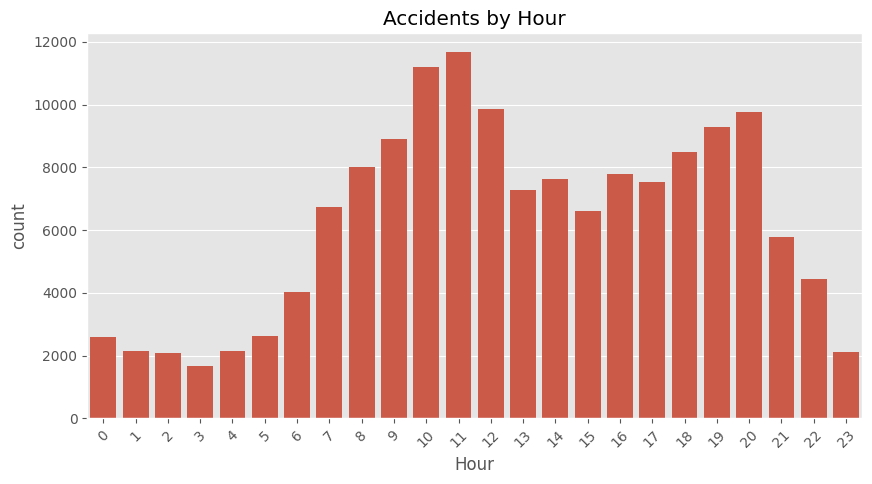

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=df)

plt.title("Accidents by Hour")
plt.xticks(rotation=45)
plt.show()

Visualization 2
Accidents by Day

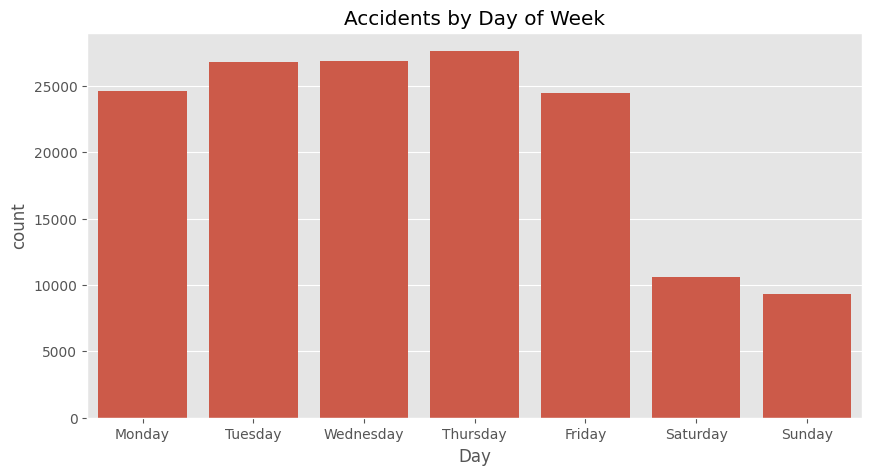

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Day',
    data=df,
    order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.title("Accidents by Day of Week")

plt.show()

Visualization 3
Top 10 Weather Conditions

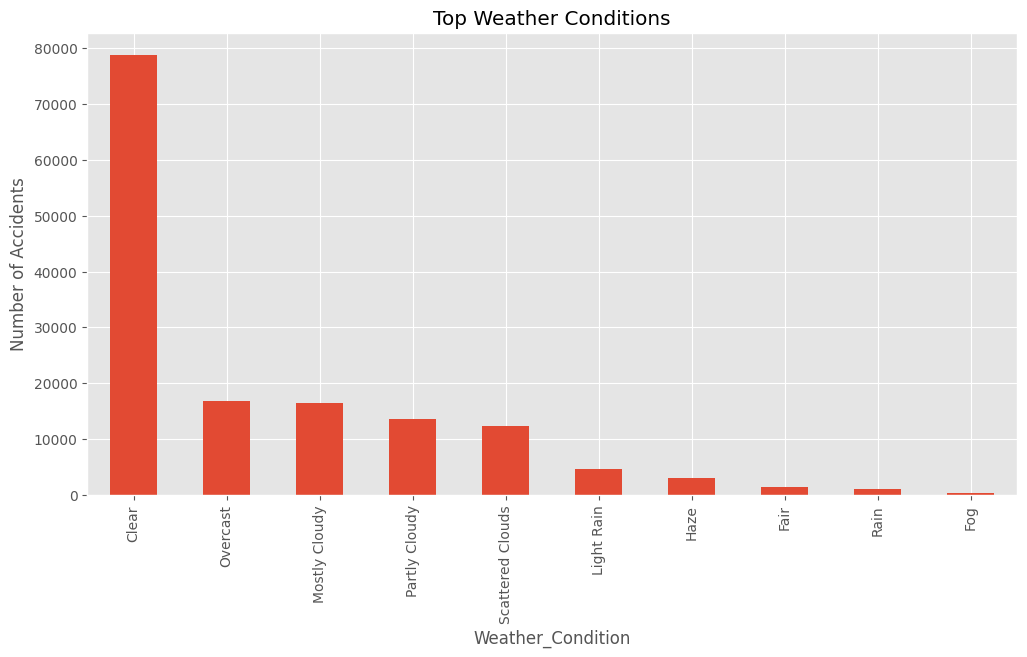

In [12]:
plt.figure(figsize=(12,6))

df['Weather_Condition'].value_counts().head(10).plot(kind='bar')

plt.title("Top Weather Conditions")

plt.ylabel("Number of Accidents")

plt.show()

Visualization 4
Road Severity

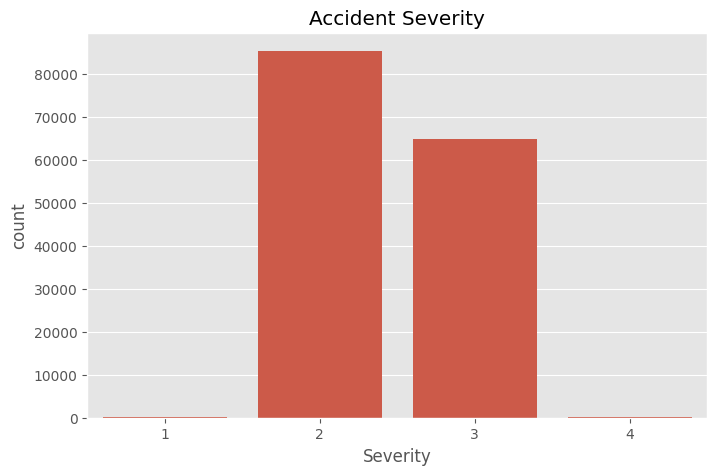

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(x='Severity', data=df)

plt.title("Accident Severity")

plt.show()

Visualization 5
Top 10 States with Most Accidents

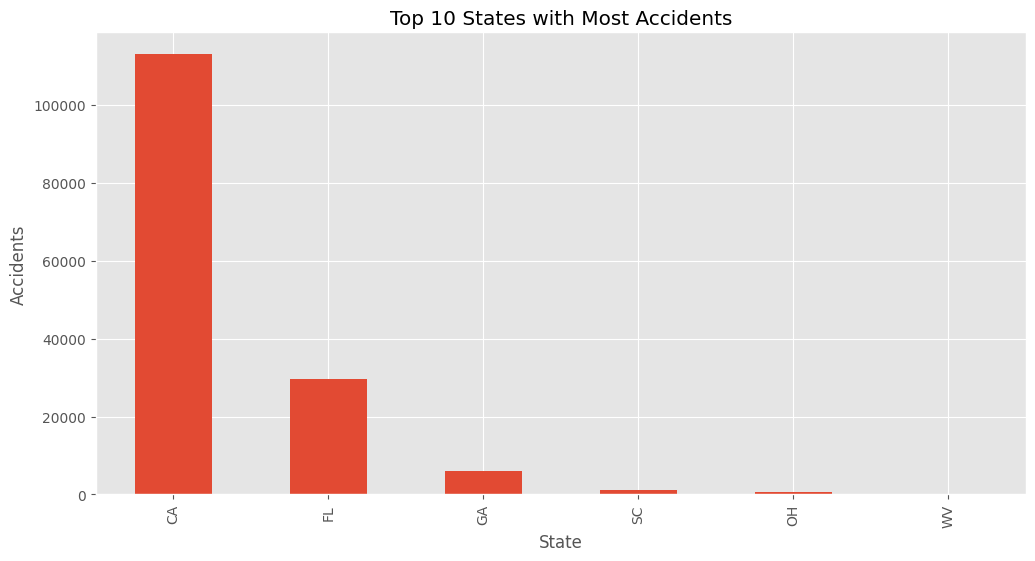

In [14]:
plt.figure(figsize=(12,6))

df['State'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 States with Most Accidents")

plt.ylabel("Accidents")

plt.show()

Visualization 6
Temperature Distribution

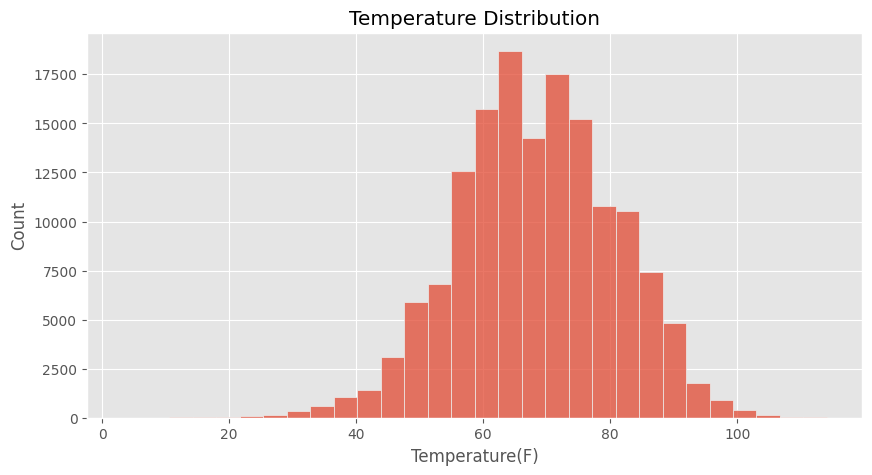

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(df['Temperature(F)'], bins=30)

plt.title("Temperature Distribution")

plt.show()

Visualization 7
Correlation Heatmap

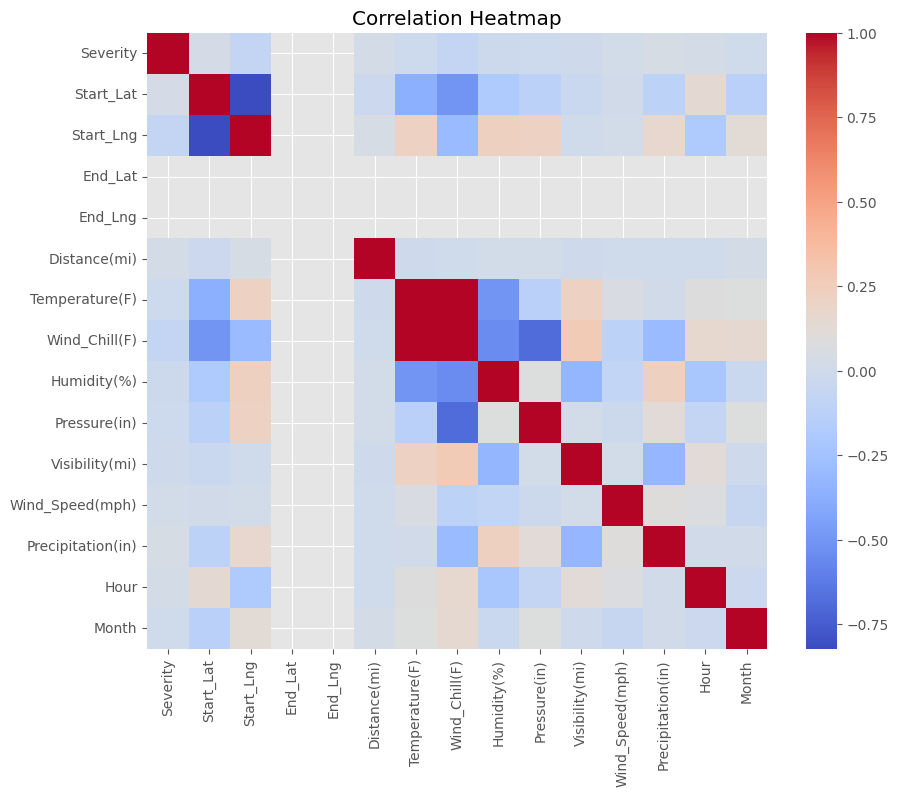

In [16]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(numeric.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Visualization 8
Accident Hotspots

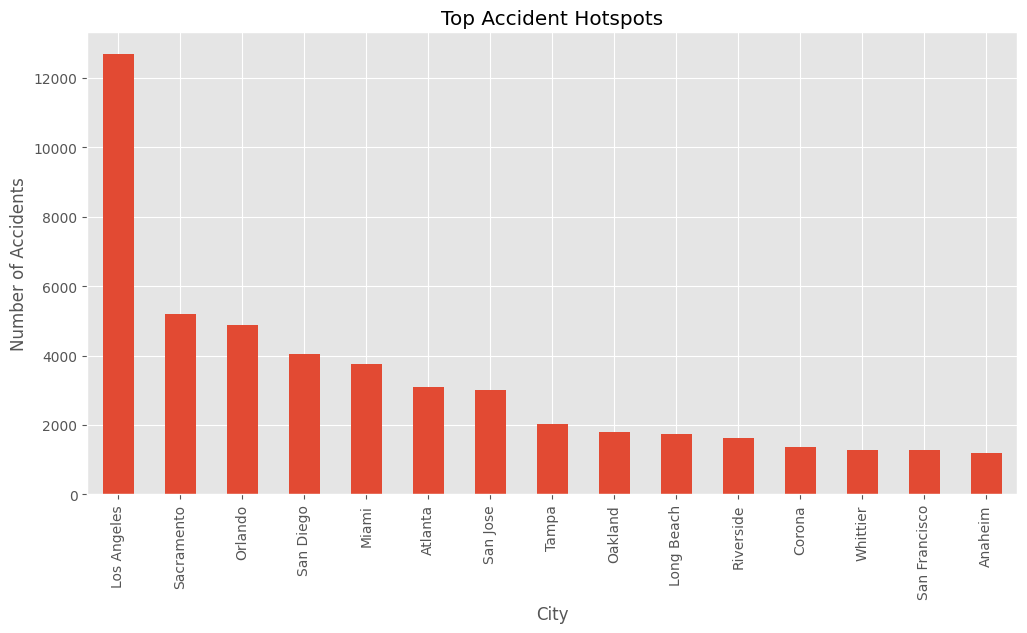

In [17]:
plt.figure(figsize=(12,6))

df['City'].value_counts().head(15).plot(kind='bar')

plt.title("Top Accident Hotspots")

plt.ylabel("Number of Accidents")

plt.show()

## Conclusion

The analysis of the US Accidents dataset revealed several important patterns.

• Accident frequency varies significantly throughout the day.

• Certain weather conditions contribute to a higher number of accidents.

• Some states and cities experience significantly more accidents than others.

• Accident severity differs across locations and road conditions.

• Data visualization helps identify accident hotspots and factors that can support better road safety planning.